# Learning to stabilize a linear system with Robustness

We follow Part 1 example (example/control/Part_1_stabilize_linear_system) and demonstrate how to learn a robust stabilizing controller for a double integrator system using [Differentiable predictive control (DPC) method](https://www.sciencedirect.com/science/article/pii/S0959152422000981) and introduce a Lipschitz estimation method [EClipsE](https://proceedings.neurips.cc/paper_files/paper/2024/hash/1419d8554191a65ea4f2d8e1057973e4-Abstract-Conference.html) to charaterize the robustness of the learned controller. 

**Differentiable Predictive Control method**:  
The DPC is a model-based policy optimization algorithm, that exploits the differentiability of a wide class of model representations for dynamical systems, including differential equations, state-space models, or various neural network architectures. In DPC, we construct a differentiable closed-loop system composed of neural control policy and system dynamics model that is to be optimized using parametric control objectives as intrinsic reward signals evaluated over a sampled distribution of the problem parameters.

<img src="./figs/DPC_simple_method.png" width="600">  


**ECLipsE**:  
The Lipschitz constant plays a crucial role in certifying the robustness of neural networks to input perturbations. ***eclipse-nn*** package provides strict, accurate, efficient, and scalable $\ell_2$-norm Lipschitz estimates on FNN. One can check examples/tutorial/part_4_Lipschitz_estimator for the demonstration on the package.

## NeuroMANCER , eclipse-nn and Dependencies

### Install (Colab only)
Skip this step when running locally.

In [1]:
!pip install neuromancer

*Note: When running on Colab, one might encounter a pip dependency error with Lida 0.0.10. This can be ignored*

In [2]:
!pip install eclipse-nn==0.1.4

In [3]:
import torch
import torch.nn as nn
from neuromancer.system import Node, System
from neuromancer.modules import blocks
from neuromancer.dataset import DictDataset
from neuromancer.constraint import variable
from neuromancer.loss import PenaltyLoss
from neuromancer.problem import Problem
from neuromancer.trainer import Trainer
from neuromancer.plot import pltCL, pltPhase


In [4]:
from eclipse_nn.LipConstEstimator import LipConstEstimator

In [5]:
import random
import numpy as np

# Python built-in random
random.seed(42)

# NumPy
np.random.seed(42)

# PyTorch (CPU and GPU)
torch.manual_seed(42)
torch.cuda.manual_seed(42)
torch.cuda.manual_seed_all(42)   # if using multi-GPU

# Make cuDNN deterministic (slower, but reproducible)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


# Node and System classes

The Node class is a simple wrapper for any callable pytorch function or nn.Module which provides names for the inputs and outputs to be used in composition of a potentially cyclic computational graph.  

In [6]:
# Double integrator parameters
nx = 2
nu = 1
A = torch.tensor([[1.2, 1.0],
                  [0.0, 1.0]])
B = torch.tensor([[1.0],
                  [0.5]])

# linear state space model
xnext = lambda x, u: x @ A.T + u @ B.T    
double_integrator = Node(xnext, ['X', 'U'], ['X'], name='integrator')

# We will define the node for the neural control policy in the Optimization Problem Section for different training and wrap the closed-loop system node.

# Training dataset generation

For a training dataset we randomly sample points away from the origin of the 2D space the system operates in. 

In [7]:
# Training dataset generation
train_data = DictDataset({'X': 3.*torch.randn(3333, 1, nx)}, name='train')  # Split conditions into train and dev
dev_data = DictDataset({'X': 3.*torch.randn(3333, 1, nx)}, name='dev')
train_loader = torch.utils.data.DataLoader(train_data, batch_size=3333,
                                           collate_fn=train_data.collate_fn, shuffle=False)
dev_loader = torch.utils.data.DataLoader(dev_data, batch_size=3333,
                                         collate_fn=dev_data.collate_fn, shuffle=False)

# Optimization problem with a system rollout of 2 time steps

We want to learn a controller that stabilizes the double integrator system. In other words we would like a control policy that pushes the system to stay at the origin. Here we offer three ways of training.  
1. Standard training. Same as example/control/Part_1_stabilize_linear_system.
2. Add penaly on the Jacobian of policy u=NN(x).
3. Add penaly on the Jacobian of closed-loop dynamic f(x,u) = f(x,NN(x)).

Method 2 and 3 are expected to yield more robustness controllers and smoother trajectories.

## Standard Training

In [8]:
# neural control policy
mlp = blocks.MLP(nx, nu, bias=True,
                 linear_map=torch.nn.Linear,
                 nonlin=torch.nn.ReLU,
                 hsizes=[20, 20, 20, 20])
policy = Node(mlp, ['X'], ['U'], name='policy')

# closed loop system definition
cl_system = System([policy, double_integrator])
# cl_system.show()

In [9]:
# Define optimization problem
u = variable('U')
x = variable('X')
action_loss = 0.0001 * (u == 0.)^2  # control penalty
regulation_loss = 10. * (x == 0.)^2  # target position
loss = PenaltyLoss([action_loss, regulation_loss], [])
problem = Problem([cl_system], loss)
optimizer = torch.optim.AdamW(policy.parameters(), lr=0.001)

In [10]:
trainer = Trainer(
    problem,
    train_loader,
    dev_loader,
    dev_loader,
    optimizer=optimizer,
    epochs=500,
    train_metric="train_loss",
    dev_metric="dev_loss",
    eval_metric='dev_loss',
    warmup=50,
)

# Train model with prediction horizon of 2
cl_system.nsteps = 2
best_model = trainer.train()

C:\Users\22384\OneDrive - purdue.edu\Purdue\Research\ECLipsE_package_application\neuromancer\src\neuromancer\constraint.py:172: UserWarning: Using a target size (torch.Size([])) that is different to the input size (torch.Size([3333, 2, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss = F.mse_loss(left, right)
C:\Users\22384\OneDrive - purdue.edu\Purdue\Research\ECLipsE_package_application\neuromancer\src\neuromancer\constraint.py:172: UserWarning: Using a target size (torch.Size([])) that is different to the input size (torch.Size([3333, 3, 2])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss = F.mse_loss(left, right)


epoch: 0  train_loss: 202.42628479003906
epoch: 1  train_loss: 201.84446716308594
epoch: 2  train_loss: 201.25
epoch: 3  train_loss: 200.6475067138672
epoch: 4  train_loss: 200.03172302246094
epoch: 5  train_loss: 199.40264892578125
epoch: 6  train_loss: 198.76254272460938
epoch: 7  train_loss: 198.11053466796875
epoch: 8  train_loss: 197.44590759277344
epoch: 9  train_loss: 196.77001953125
epoch: 10  train_loss: 196.0867156982422
epoch: 11  train_loss: 195.40872192382812
epoch: 12  train_loss: 194.7261962890625
epoch: 13  train_loss: 194.01625061035156
epoch: 14  train_loss: 193.2728271484375
epoch: 15  train_loss: 192.4952392578125
epoch: 16  train_loss: 191.68118286132812
epoch: 17  train_loss: 190.82876586914062
epoch: 18  train_loss: 189.9380645751953
epoch: 19  train_loss: 189.00718688964844
epoch: 20  train_loss: 188.03286743164062
epoch: 21  train_loss: 187.0134735107422
epoch: 22  train_loss: 185.9462890625
epoch: 23  train_loss: 184.82933044433594
epoch: 24  train_loss: 183.6

## Train with regularization on the Jacobian of policy u=NN(x)

In [11]:
# neural control policy
mlp_reg = blocks.MLP(nx, nu, bias=True,
                 linear_map=torch.nn.Linear,
                 nonlin=torch.nn.ReLU,
                 hsizes=[20, 20, 20, 20])
policy_reg = Node(mlp_reg, ['X'], ['U'], name='policy')




def _jac_fro_node(X):
    # X comes in as [B, nx].
    with torch.enable_grad():
        X = X.detach().requires_grad_(True)          # leaf with grad
        U = mlp_reg(X)                                # [B, nu]
        if U.dim() == 1:
            U = U.unsqueeze(-1)

        sqsum = 0.0
        for j in range(U.shape[1]):
            g = torch.autograd.grad(
                U[:, j].sum(), X,
                create_graph=True, retain_graph=True
            )[0]                                      # [B, nx]
            sqsum = sqsum + (g * g).sum(dim=1)        # [B]

        Jfro = torch.sqrt(sqsum + 1e-12).unsqueeze(-1)  # [B, 1]
    return Jfro

jac_fro = Node(_jac_fro_node, ['X'], ['Jfro'], name='jac_fro')

# closed loop system definition (add the jac_fro node)
cl_system_reg = System([policy_reg, double_integrator, jac_fro])

In [12]:
# variables
u = variable('U')
x = variable('X')
j = variable('Jfro')   # from the Jacobian-Fro node

action_loss     =  0.0001 * (u == 0.)^2       
regulation_loss = 10. * (x == 0.)^2     
jac_loss    = 5 * (j == 0.)^2 

loss_reg = PenaltyLoss([action_loss, regulation_loss,jac_loss], [])
problem_reg = Problem([cl_system_reg], loss_reg)

optimizer = torch.optim.AdamW(policy_reg.parameters(), lr=0.003)

In [13]:
trainer_reg = Trainer(
    problem_reg,
    train_loader,
    dev_loader,
    dev_loader,
    optimizer=optimizer,
    epochs=500,
    train_metric="train_loss",
    dev_metric="dev_loss",
    eval_metric='dev_loss',
    warmup=50,
)


# Train model with prediction horizon of 2
cl_system_reg.nsteps = 2
best_model_reg = trainer_reg.train()

epoch: 0  train_loss: 204.56048583984375
epoch: 1  train_loss: 202.84828186035156
epoch: 2  train_loss: 201.67640686035156
epoch: 3  train_loss: 200.6287384033203
epoch: 4  train_loss: 199.54443359375
epoch: 5  train_loss: 198.3040313720703
epoch: 6  train_loss: 196.8018798828125
epoch: 7  train_loss: 194.991455078125
epoch: 8  train_loss: 192.88729858398438
epoch: 9  train_loss: 190.4730682373047
epoch: 10  train_loss: 187.6907501220703
epoch: 11  train_loss: 184.51220703125
epoch: 12  train_loss: 180.92430114746094
epoch: 13  train_loss: 176.89051818847656
epoch: 14  train_loss: 172.3829803466797
epoch: 15  train_loss: 167.38644409179688
epoch: 16  train_loss: 161.90895080566406
epoch: 17  train_loss: 155.96405029296875
epoch: 18  train_loss: 149.53794860839844
epoch: 19  train_loss: 142.64877319335938
epoch: 20  train_loss: 135.33851623535156
epoch: 21  train_loss: 127.67012786865234
epoch: 22  train_loss: 119.73432922363281
epoch: 23  train_loss: 111.6493911743164
epoch: 24  train_

## Train with regularization on the Jacobian of  closed-loop dynamic f(x,u) = f(x,NN(x)). (Very expensive, takes hours)

In [14]:
mlp_reg_cl = blocks.MLP(nx, nu, bias=True,
                 linear_map=torch.nn.Linear,
                 nonlin=torch.nn.ReLU,
                 hsizes=[20, 20, 20, 20])
policy_reg_cl = Node(mlp_reg_cl, ['X'], ['U'], name='policy')


def make_jac_cl_node(policy_node):
    """Node: inputs ['X'] (batch,nx) -> outputs ['Jcl'] (batch,1) with ||A + B J_pi||_F^2."""
    policy_module = policy_node.callable  # underlying nn.Module: X -> U

    def _forward(X):                      # <-- NOTE: positional tensor, not dict
        X = X.requires_grad_(True)

        Bsize = X.shape[0]
        vals = []
        for b in range(Bsize):
            xb = X[b]                    # (nx,)

            def f_single(x_single):      # R^nx -> R^nu
                return policy_module(x_single.unsqueeze(0)).squeeze(0)

            J_pi = torch.autograd.functional.jacobian(f_single, xb, create_graph=True)  # (nu,nx)
            J_cl = A + B @ J_pi                                                          # (nx,nx)
            vals.append(torch.linalg.norm(J_cl, ord='fro'))                          # scalar

        Jcl_fro = torch.stack(vals, dim=0).unsqueeze(1)  # (batch,1)
        return Jcl_fro                                   

    return Node(_forward, ['X'], ['Jcl_fro'], name='jac_cl')



jac_cl_node = make_jac_cl_node(policy_reg_cl)

# closed loop system definition (add the jac_fro node)
cl_system_reg_cl = System([policy_reg_cl, double_integrator, jac_cl_node])

In [15]:
# variables
u = variable('U')
x = variable('X')
jcl = variable('Jcl_fro')   # from the Jacobian-Fro node

action_loss     =  0.0001 * (u == 0.)^2       
regulation_loss = 10. * (x == 0.)^2     
jac_cl_loss    = 5 * (jcl == 0.)^2 

loss_reg_cl = PenaltyLoss([action_loss, regulation_loss,jac_cl_loss], [])
problem_reg_cl = Problem([cl_system_reg_cl], loss_reg_cl)

In [16]:
optimizer = torch.optim.AdamW(policy_reg_cl.parameters(), lr=0.003)

trainer_reg_cl = Trainer(
    problem_reg_cl,
    train_loader,
    dev_loader,
    dev_loader,
    optimizer=optimizer,
    epochs=500,
    train_metric="train_loss",
    dev_metric="dev_loss",
    eval_metric='dev_loss',
    warmup=50,
)


# Train model with prediction horizon of 2
cl_system_reg_cl.nsteps = 2
best_model_reg_cl = trainer_reg_cl.train()

epoch: 0  train_loss: 219.83505249023438
epoch: 1  train_loss: 219.1568603515625
epoch: 2  train_loss: 218.44680786132812
epoch: 3  train_loss: 217.7032928466797
epoch: 4  train_loss: 216.91046142578125
epoch: 5  train_loss: 216.03236389160156
epoch: 6  train_loss: 215.04632568359375
epoch: 7  train_loss: 213.9205780029297
epoch: 8  train_loss: 212.64161682128906
epoch: 9  train_loss: 211.18968200683594
epoch: 10  train_loss: 209.53427124023438
epoch: 11  train_loss: 207.63876342773438
epoch: 12  train_loss: 205.47491455078125
epoch: 13  train_loss: 203.01162719726562
epoch: 14  train_loss: 200.2211151123047
epoch: 15  train_loss: 197.0832061767578
epoch: 16  train_loss: 193.56402587890625
epoch: 17  train_loss: 189.6116943359375
epoch: 18  train_loss: 185.19290161132812
epoch: 19  train_loss: 180.270751953125
epoch: 20  train_loss: 174.8209228515625
epoch: 21  train_loss: 168.82186889648438
epoch: 22  train_loss: 162.26980590820312
epoch: 23  train_loss: 155.180419921875
epoch: 24  tr

# Evaluate best model on a system rollout 

## Standard Training

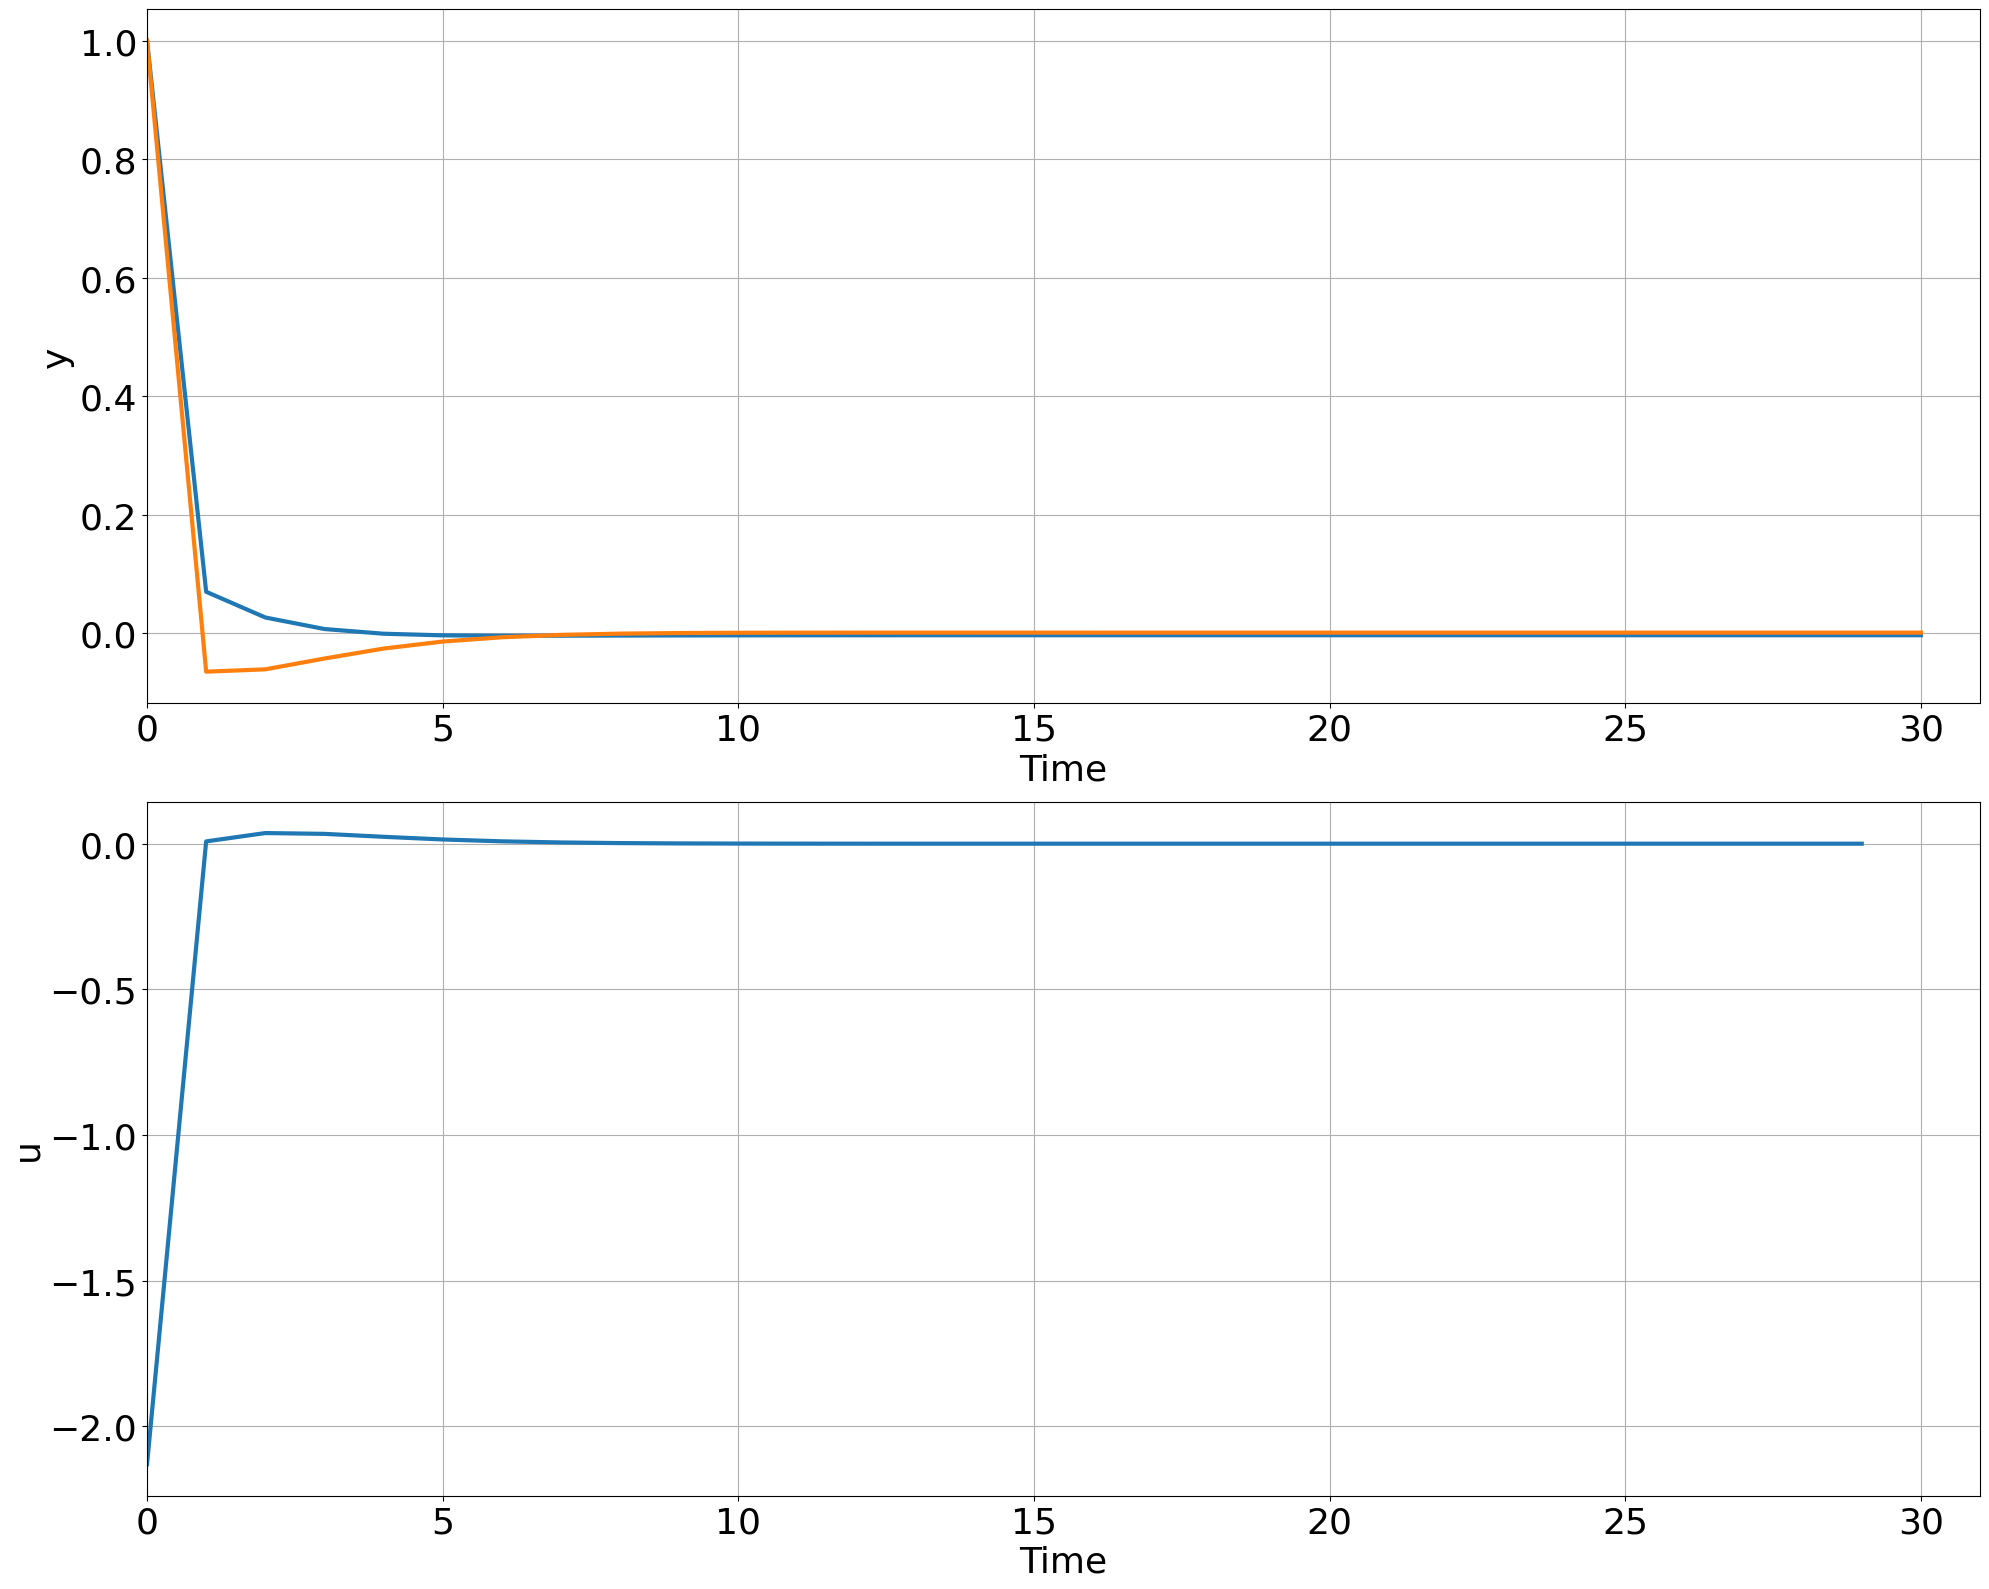

<Figure size 640x480 with 0 Axes>

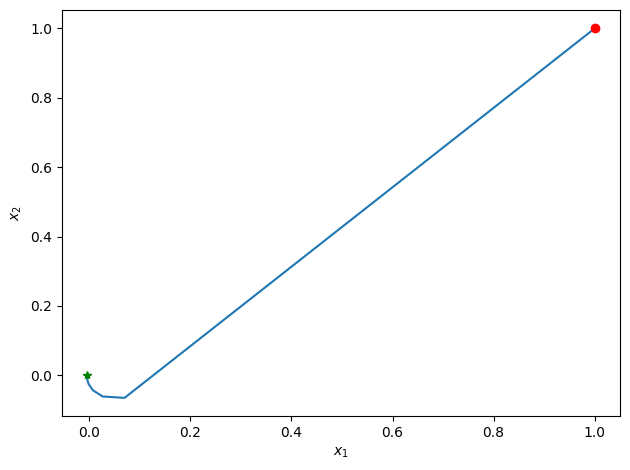

<Figure size 640x480 with 0 Axes>

In [17]:
# Test best model with prediction horizon of 50
problem.load_state_dict(best_model)
data = {'X': torch.ones(1, 1, nx, dtype=torch.float32)}
nsteps = 30
cl_system.nsteps = nsteps
trajectories = cl_system(data)
pltCL(Y=trajectories['X'].detach().reshape(nsteps+1, 2), U=trajectories['U'].detach().reshape(nsteps, 1), figname='cl.png')
pltPhase(X=trajectories['X'].detach().reshape(nsteps+1, 2), figname='phase.png')

## With Regularization on the Jacobian of policy u=NN(x)

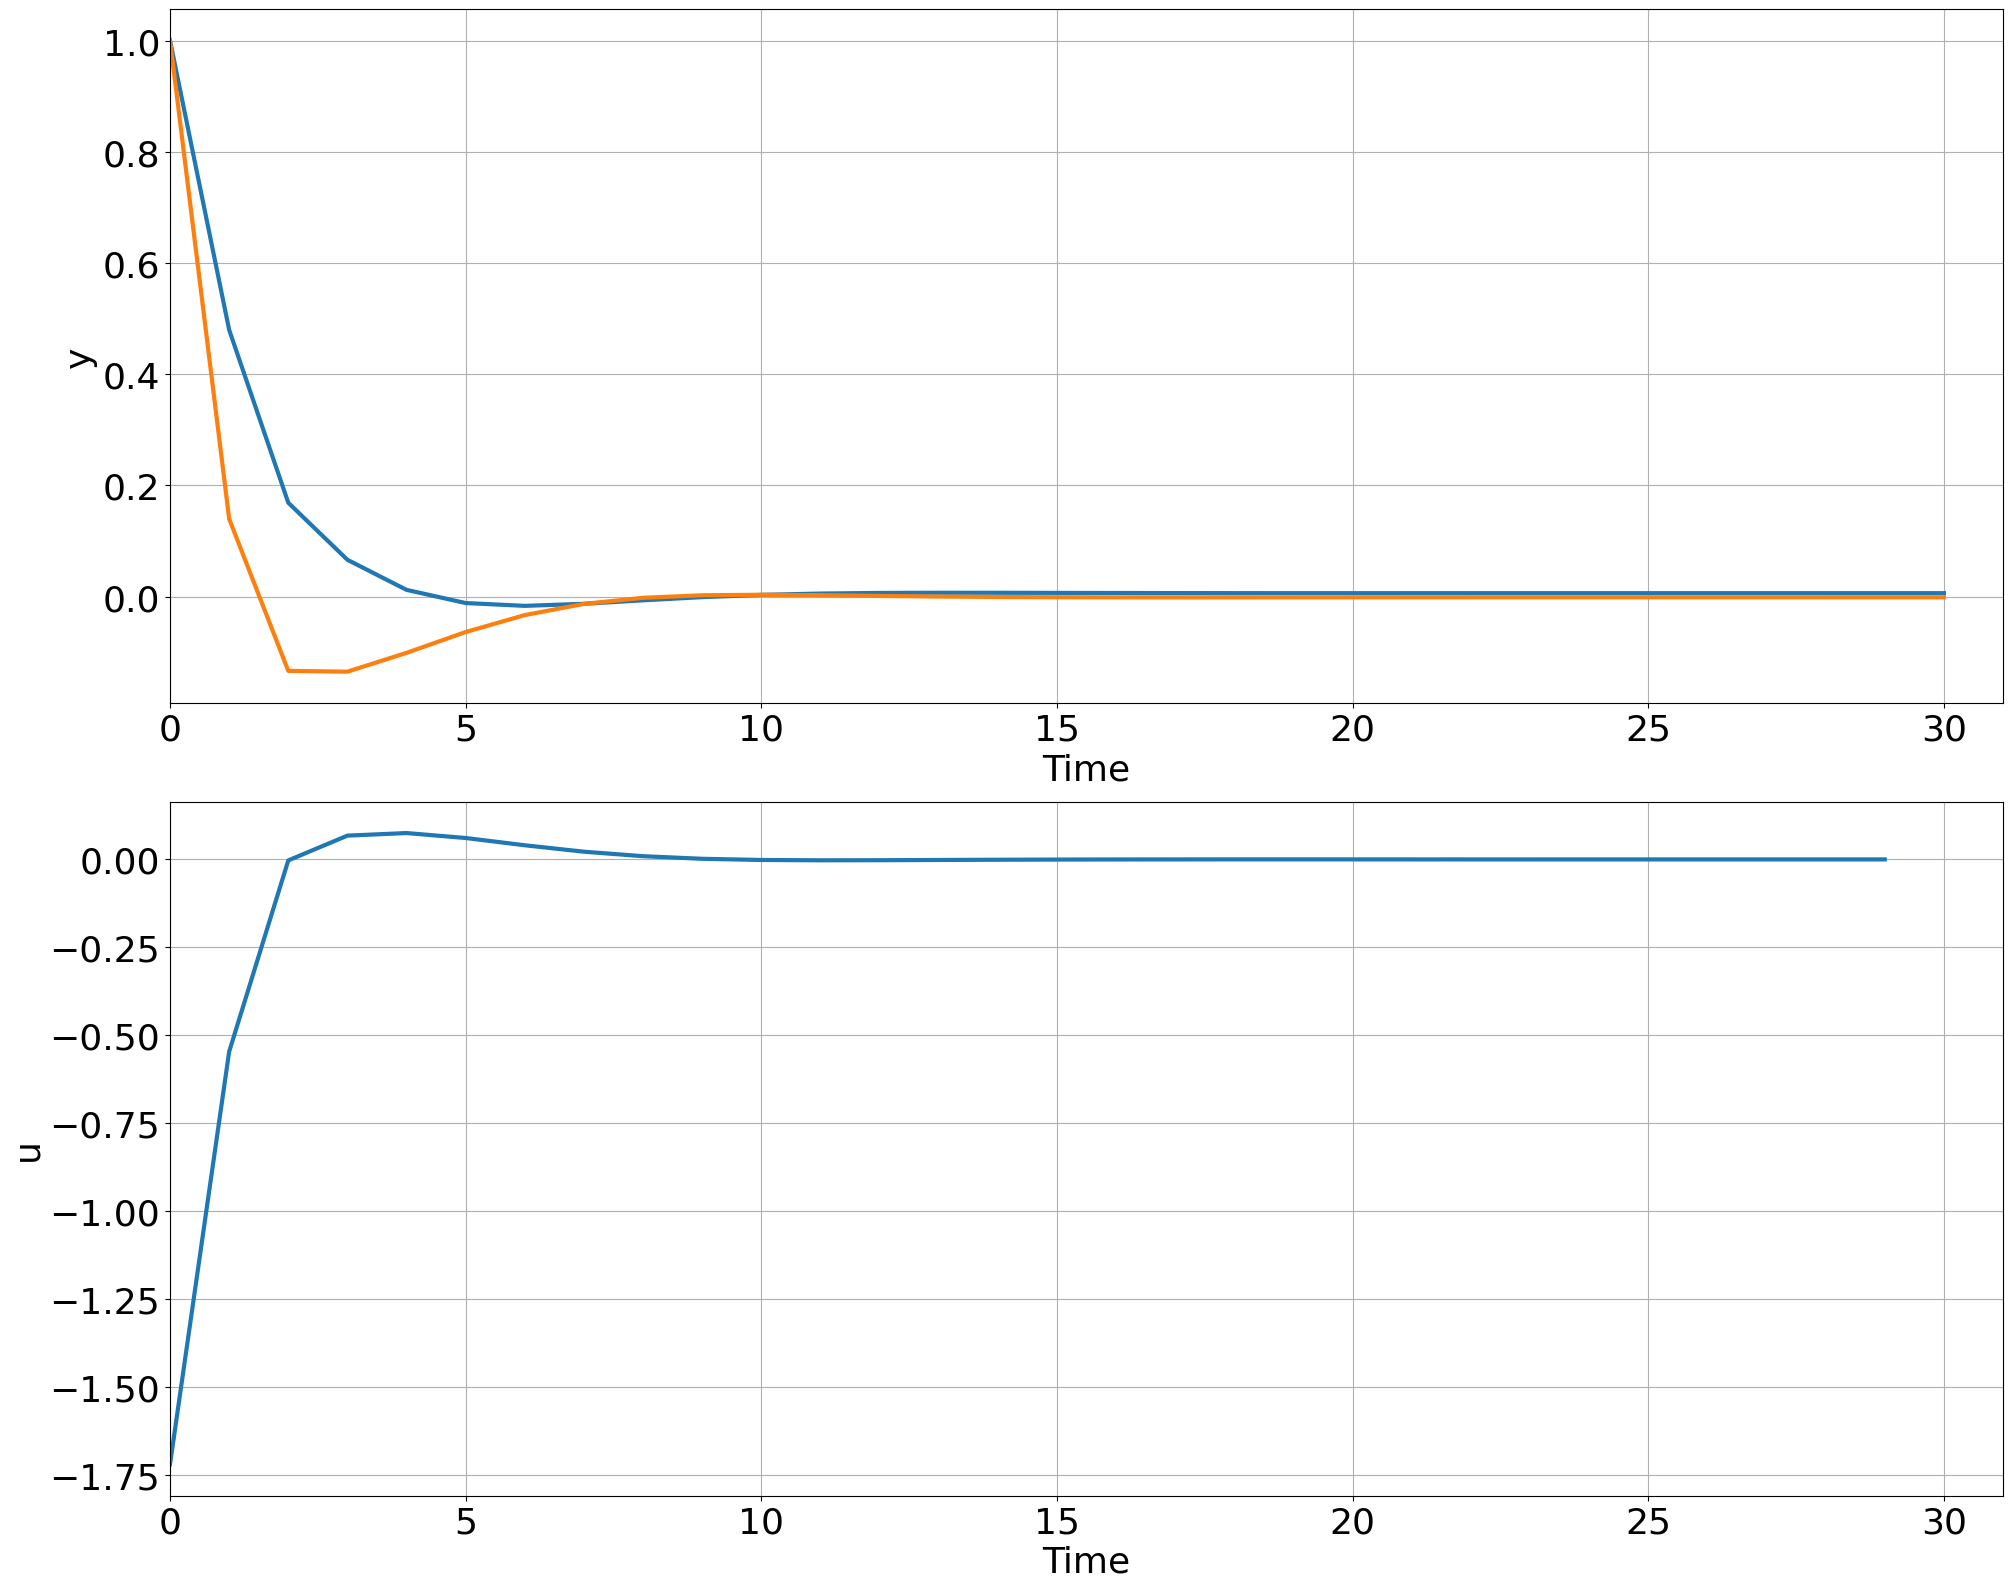

<Figure size 640x480 with 0 Axes>

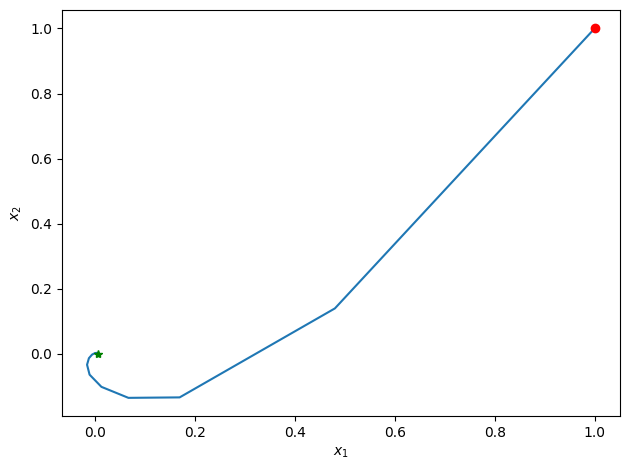

<Figure size 640x480 with 0 Axes>

In [18]:
# Test best model with prediction horizon of 50
problem_reg.load_state_dict(best_model_reg)
data = {'X': torch.ones(1, 1, nx, dtype=torch.float32)}
nsteps = 30
cl_system_reg.nsteps = nsteps
trajectories = cl_system_reg(data)
pltCL(Y=trajectories['X'].detach().reshape(nsteps+1, 2), U=trajectories['U'].detach().reshape(nsteps, 1), figname='cl.png')
pltPhase(X=trajectories['X'].detach().reshape(nsteps+1, 2), figname='phase.png')

## With Regularization on the Jacobian of  closed-loop dynamic f(x,u) = f(x,NN(x)).

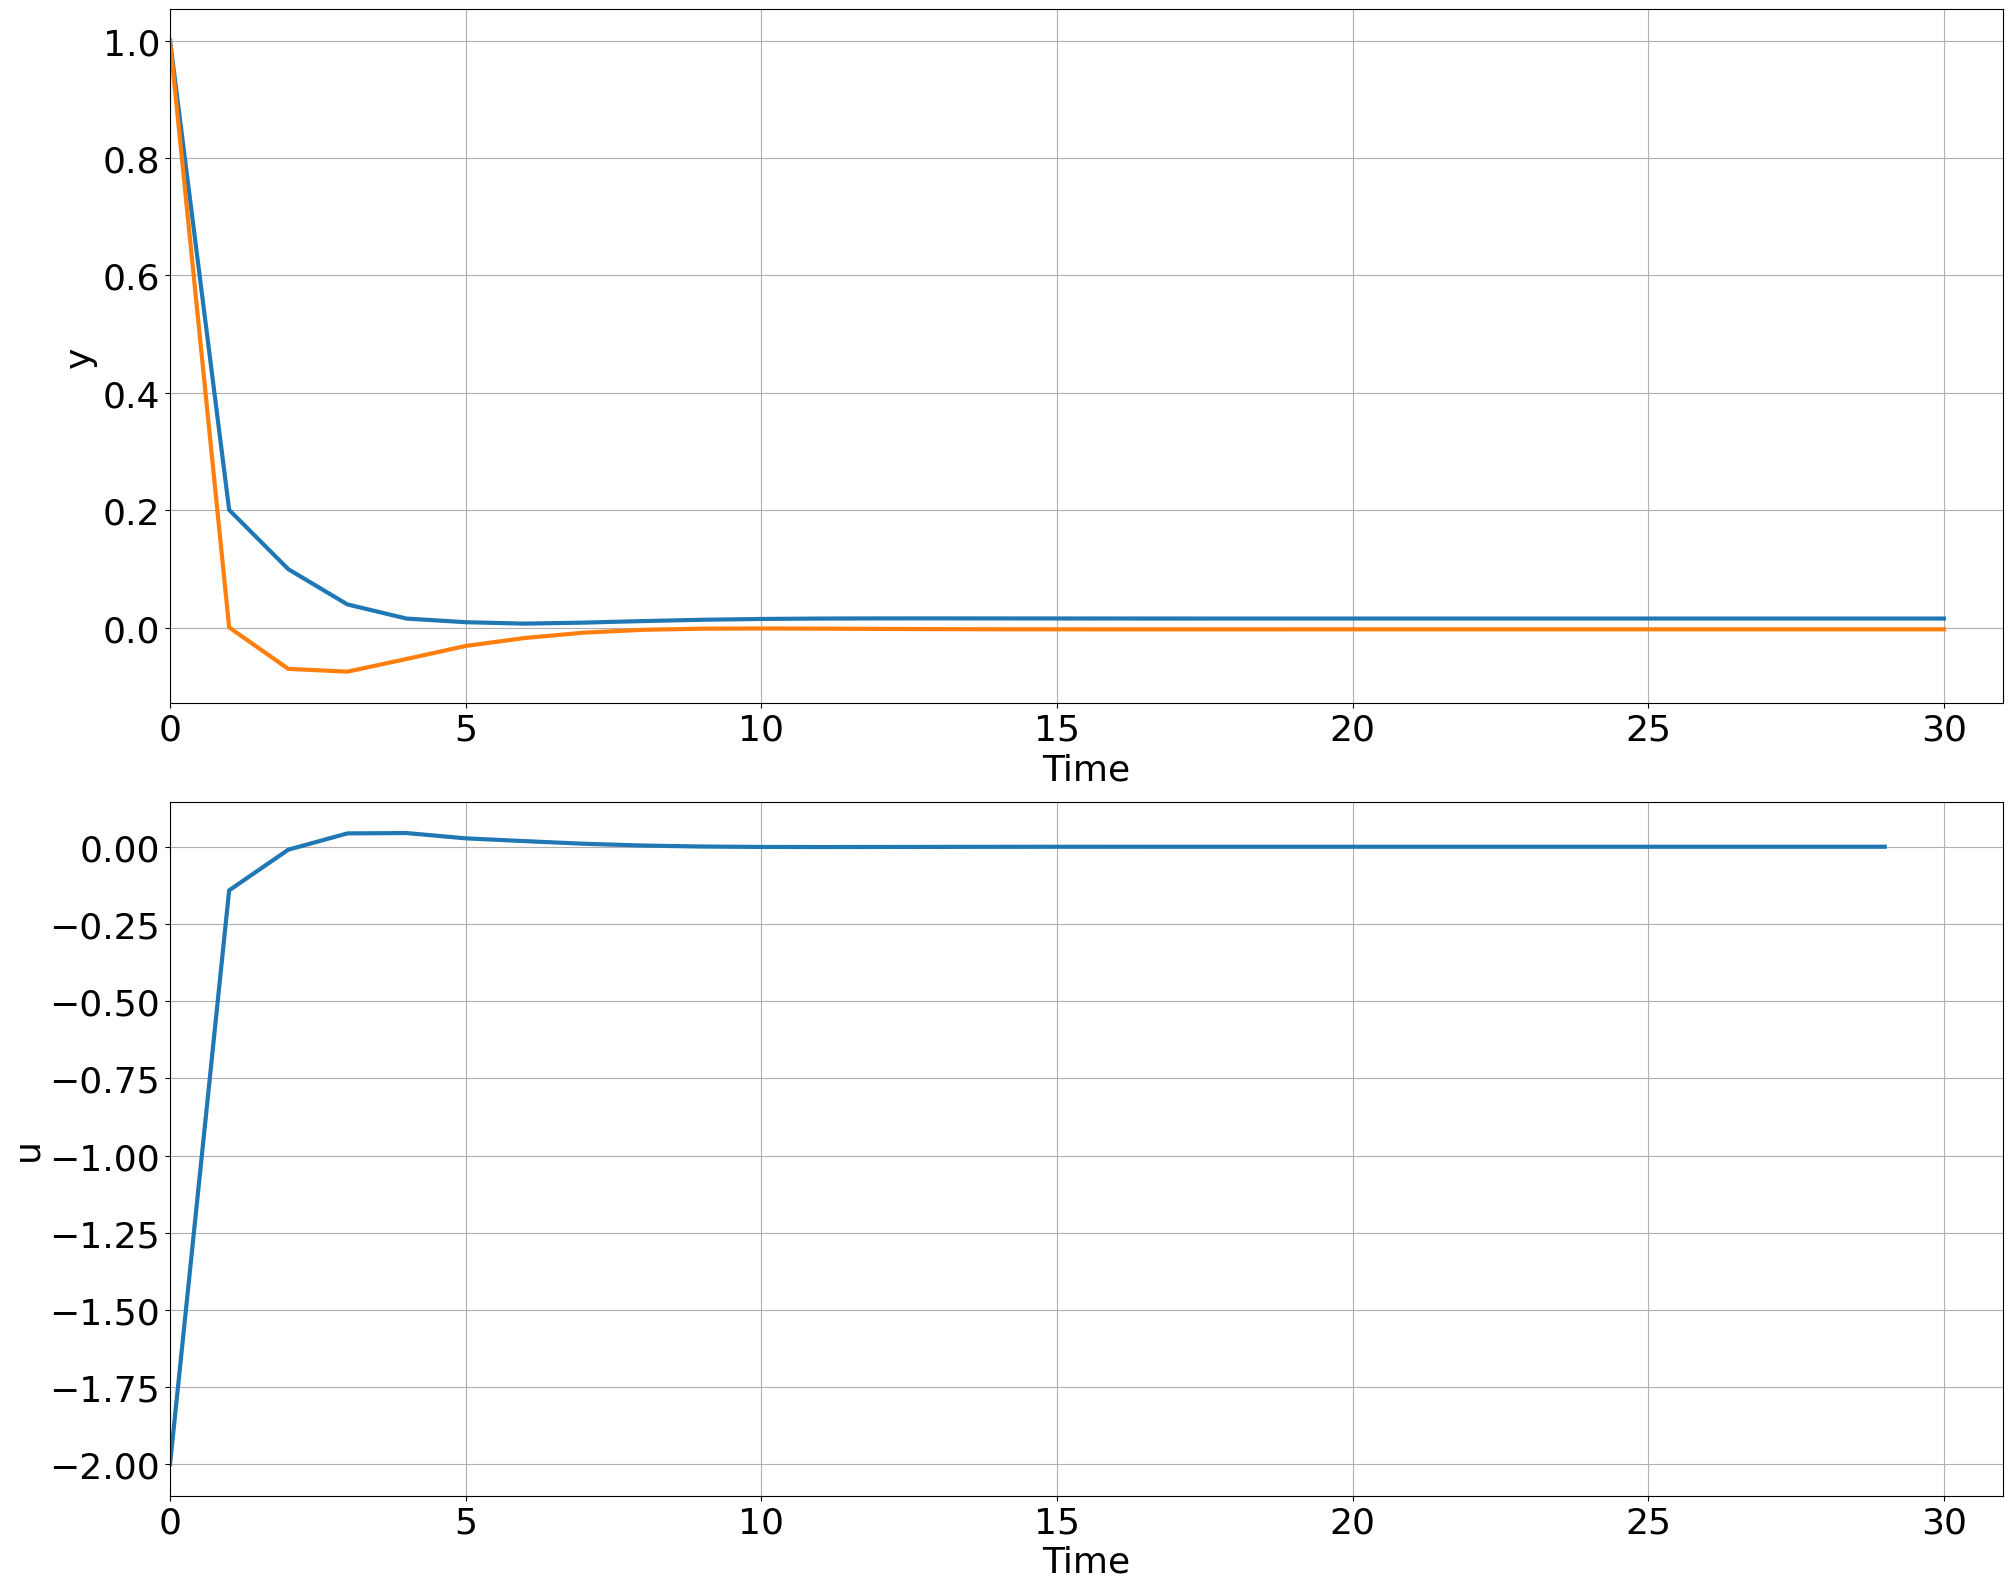

<Figure size 640x480 with 0 Axes>

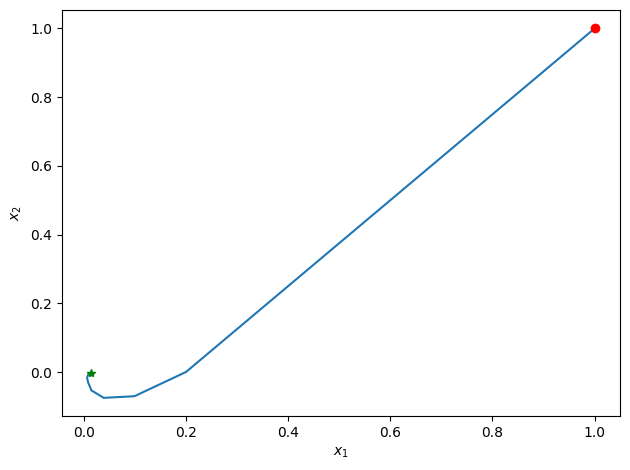

<Figure size 640x480 with 0 Axes>

In [19]:
# Test best model with prediction horizon of 50
problem_reg_cl.load_state_dict(best_model_reg_cl)
data = {'X': torch.ones(1, 1, nx, dtype=torch.float32)}
nsteps = 30
cl_system_reg_cl.nsteps = nsteps
trajectories = cl_system_reg_cl(data)
pltCL(Y=trajectories['X'].detach().reshape(nsteps+1, 2), U=trajectories['U'].detach().reshape(nsteps, 1), figname='cl.png')
pltPhase(X=trajectories['X'].detach().reshape(nsteps+1, 2), figname='phase.png')

## Observation
1. All of the three controllers manage to stabilize the system.
2. If we penalize the Jacobian of the controller or the Jacobian of the closed-loop dynamics, there are less acute / sharp change in the input given by the controller. Also, the corresponding trajectories become smoother.
3. Comparing two different way of regularization, we observe that regularizing on the closed-loop dynamics pushes towards the equilibrium faster than regularizing on the neural controller only while achieving similar smoothness in both trajectory and control input.
   
The enhanced smoothness in control input and the trajectory is desirable for controller design.

# Robustness Testing
Now we estimate the Lipschitz constant of all the three neural controllers u=NN(x).

In [20]:
# Get NN model parameters
def to_sequential(neuromancer_mlp: nn.Module) -> nn.Sequential:
    """
    Convert neuromancer.blocks.MLP (built with linear_map=torch.nn.Linear)
    into a vanilla torch.nn.Sequential with the same weights/activations.
    """
    # Neuromancer MLP exposes ModuleLists: .linear (Linear layers) and .nonlin (activations)
    src_linear = list(neuromancer_mlp.linear)
    src_nonlin = list(neuromancer_mlp.nonlin)

    layers = []
    for lin, act in zip(src_linear, src_nonlin):
        # Recreate Linear with same shape & bias usage
        new_lin = nn.Linear(lin.in_features, lin.out_features, bias=(lin.bias is not None))
        # Copy parameters
        new_lin.weight.data.copy_(lin.weight.data)
        if lin.bias is not None:
            new_lin.bias.data.copy_(lin.bias.data)
        layers.append(new_lin)

        # Recreate activation (skip if Identity)
        if not isinstance(act, nn.Identity):
            layers.append(act.__class__())

    return nn.Sequential(*layers)

In [21]:
seq = to_sequential(mlp)
est = LipConstEstimator(model=seq)
# est.model_review()
lip = est.estimate(method='ECLipsE_Fast')
print(f"The Lipschitz estimate for controller from standard training is {lip}")

The Lipschitz estimate for controller from standard training is 3.5701943197528556


In [22]:
seq_reg = to_sequential(mlp_reg)
est_reg = LipConstEstimator(model=seq_reg)
lip_reg = est_reg.estimate(method='ECLipsE_Fast')
print(f"The Lipschitz estimate for controller trained with regularization on the Jacobian of policy u=NN(x)  is {lip_reg}")

The Lipschitz estimate for controller trained with regularization on the Jacobian of policy u=NN(x)  is 2.880565150275897


In [23]:
seq_reg_cl = to_sequential(mlp_reg_cl)
est_reg_cl = LipConstEstimator(model=seq_reg_cl)
lip_reg_cl = est_reg_cl.estimate(method='ECLipsE_Fast')
print(f"The Lipschitz estimate for controller trained with regularization on the Jacobian of policy u=NN(x)  is {lip_reg_cl}")

The Lipschitz estimate for controller trained with regularization on the Jacobian of policy u=NN(x)  is 2.841466971008887


## Observation
The Lipschitz estimates of controllers trained with regularization on the Jacobian of the controller and the Jacobian of the closed-loop dynamics are similar, and are at the same time smaller than the one from standard training. It aligns with the enhanced smoothness in control input and the trajectory.